#                        AFCON 2023 Final - Match Analysis Dashboard

## Overview
This notebook builds a professional match analysis dashboard for the AFCON 2023 Final between Nigeria and Côte d'Ivoire (February 11, 2024). Using StatsBomb open event data and the mplsoccer library, we construct a multi-panel visual dashboard covering passing networks, shot maps, match statistics, and xG flow.

## 1. Import the core libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsbombpy import sb
from mplsoccer import Pitch, Sbopen, VerticalPitch
from PIL import Image

## 2. Colour Palette
We define the global colour constants used throughout the dashboard. The dark navy background (#1E2A3A) ensures all panels are clearly visible, with light text and vivid team colours providing strong contrast.

In [2]:
PITCH_COLOR = "#22312b"   
LINE_COLOR  = "#c7d5cc"   
DASH_BG     = "#1E2A3A"    
TEXT_COLOR  = "#E8EDF2"    
ACCENT_GREY = "#2A3A4E"    


## 3. Match Configuration

### 3.1 Match details

In [3]:
# Match details
competition_id = 1267
season_id = 107
match_id = 3923881

### 3.2 Load events & Split by team

In [4]:
df = sb.events(match_id).sort_values(by=['index'])
teamA = df[df['team'] == 'Nigeria']
teamB = df[df['team'] == "Côte d'Ivoire"]

### 3.3 Team colors and IDs

In [5]:
NIGERIA_COLOR    = "#008751" 
IVORYCOAST_COLOR = "#F77F00" 
NIGERIA_TEAM_ID    = 771
IVORYCOAST_TEAM_ID = 793

## 4. Functions to Create Visualizations

### 4.1 Shot map function
Draws a vertical half-pitch shot map for a given team. `Goals` are filled with the team colour; `non-goals` are shown as `white circles` with a coloured edge. Circle size scales with `xG` value.

In [6]:
def create_shotmap(team, ax, team_color="#008751"):
    pitch = VerticalPitch(
        pitch_type='statsbomb', half=True,
        pitch_color=PITCH_COLOR, line_color=LINE_COLOR,
        linewidth=1.2
    )
    pitch.draw(ax=ax)
    
    # the shots data is in the 'type' column
    team = team[team['type']=='Shot']
    
    # Filter down to just the columns we need
    team = team[['team', 'player', 'location', 'shot_outcome', 'shot_statsbomb_xg', 'shot_type']]
    team[['x', 'y']] = team['location'].apply(pd.Series)
    
    # Draw the shotmap
    for x in team.to_dict(orient='records'):
        is_goal = x['shot_outcome'] == 'Goal'
        pitch.scatter(
            x=x['x'], y=x['y'], ax=ax,
            s=600 * x['shot_statsbomb_xg'],
            color=team_color if is_goal else 'white',
            edgecolors=team_color, linewidths=1.5,
            alpha=0.85, zorder=3
        )


### 4.2 Passing network function
Builds a passing network showing average player positions (nodes) and pass volume between pairs (edges). Only `completed passes before the first substitution` are used, following the standard passing network methodology.

In [7]:
def create_passnetwork(team_name_str, ax,
                       match_id,
                       node_color="#F77F00",
                       edge_color="#009A44",
                       bg="#22312b",
                       line="#c7d5cc",
                       min_passes_between=3):
    """
    Draw a passing network for a given team on the supplied Axes.

    Combine sb.events & Sbopen to get a flexible workflow :
      - sb.events()   → pass filtering  (type, pass_outcome, pass_type)
      - Sbopen/parser → position_id / player_name for position abbreviations

    Parameters
    ----------
    team_name_str : str
        The team name as it appears in StatsBomb data, e.g. "Nigeria"
        or "Côte d'Ivoire".
    ax : matplotlib.axes.Axes
        Axes to draw on.
    match_id : int
        StatsBomb match ID.
    node_color, edge_color, bg, line : str
        Colour strings.
    min_passes_between : int
        Minimum completed passes between a pair to show the edge.
    """

    # ------------------------------------------------------------------
    # 0. Formation lookup
    # ------------------------------------------------------------------
    formation_dict = {
        1: 'GK',  2: 'RB',  3: 'RCB', 4: 'CB',  5: 'LCB', 6: 'LB',
        7: 'RWB', 8: 'LWB', 9: 'RDM', 10: 'CDM', 11: 'LDM',
        12: 'RM', 13: 'RCM', 14: 'CM', 15: 'LCM', 16: 'LM',
        17: 'RW', 18: 'RAM', 19: 'CAM', 20: 'LAM', 21: 'LW',
        22: 'RCF', 23: 'ST', 24: 'LCF', 25: 'SS'
    }

    # ------------------------------------------------------------------
    # 1. Load data 
    #    sb.events    - pass columns (outcome, type, recipient, etc.)
    #    Sbopen       - position_id
    # ------------------------------------------------------------------
    parser = Sbopen()
    df_event, _, _, _ = parser.event(match_id)

    # sb gives us the rich pass columns we need for filtering
    df_sb = sb.events(match_id)
    df_sb['newsecond'] = 60 * df_sb['minute'] + df_sb['second']
    df_sb = df_sb.sort_values('newsecond')

    # Filter to the requested team
    team_sb  = df_sb[df_sb['team'] == team_name_str].copy()
    team_evt = df_event[df_event['team_name'] == team_name_str].copy()

    # ------------------------------------------------------------------
    # 2. Derive per-player position abbreviations  (Sbopen path)
    #    df_event has `player_name` and `position_id`
    # ------------------------------------------------------------------
    pos_per_player = (
        team_evt
        .dropna(subset=['position_id'])
        .groupby('player_name')['position_id']
        .agg(lambda x: int(x.value_counts().index[0]))
    )
    position_abbr_map = pos_per_player.map(formation_dict)

    # ------------------------------------------------------------------
    # 3. Passer & recipient columns  (sb path)
    #    sb.events() uses 'player', 'pass_recipient' (name strings)
    #    and 'player_id', 'pass_recipient_id' (UUIDs)
    # ------------------------------------------------------------------
    team_sb['passer']    = team_sb['player_id']
    team_sb['recipient'] = team_sb['pass_recipient_id']

    # ------------------------------------------------------------------
    # 4. Filter: completed open-play passes only  (sb path)
    #    sb.events() returns NaN for successful passes (no outcome string)
    #    and NaN for open-play passes (no pass_type string) - same as
    #    Sbopen, so .isna() is correct for both
    # ------------------------------------------------------------------
    passes_df = team_sb[team_sb['type'] == 'Pass'].copy()

    # Completed passes → pass_outcome is NaN
    passes_df = passes_df[passes_df['pass_outcome'].isna()].copy()

    # Open-play passes → pass_type is NaN
    if 'pass_type' in passes_df.columns:
        passes_df = passes_df[passes_df['pass_type'].isna()].copy()

    # Label them for clarity
    passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna('Successful')
    completions = passes_df[passes_df['pass_outcome'] == 'Successful'].copy()

    # Unpack location → x, y
    completions[['x', 'y']] = completions['location'].apply(pd.Series)

    # ------------------------------------------------------------------
    # 5. Restrict to before first substitution
    # ------------------------------------------------------------------
    sub_df    = team_sb[team_sb['type'] == 'Substitution']
    first_sub = sub_df['newsecond'].min()
    if pd.isna(first_sub) or first_sub <= (60 * 45):
        first_sub = 60 * 45
    completions = completions[completions['newsecond'] < first_sub]

    # ------------------------------------------------------------------
    # 6. Node table
    # ------------------------------------------------------------------
    node_data = (
        completions
        .groupby('player')
        .agg(x=('x', 'mean'), y=('y', 'mean'), passes_made=('id', 'count'))
        .reset_index()
    )
    # Map position abbreviation via player name (same key as position_abbr_map)
    node_data['position_abbreviation'] = node_data['player'].map(position_abbr_map)

    # ------------------------------------------------------------------
    # 7. Links table
    # ------------------------------------------------------------------
    links = (
        completions
        .groupby(['player', 'pass_recipient'])
        .id.count()
        .reset_index(name='pass_count')
    )
    
    links = links[links['pass_count'] >= min_passes_between].copy()

    # ------------------------------------------------------------------
    # 8. Draw pitch
    # ------------------------------------------------------------------
    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color=bg,
        line_color=line,
        linewidth=1.0
    )
    pitch.draw(ax=ax)

    # ------------------------------------------------------------------
    # 9. Edges
    # ------------------------------------------------------------------
    pos_lookup = node_data.set_index('player')[['x', 'y']].to_dict('index')
    links_plot  = links.sort_values('pass_count', ascending=False).copy()
    max_passes  = links_plot['pass_count'].max() if not links_plot.empty else 1
    w_min, w_max = 0.5, 5.0

    for _, row in links_plot.iterrows():
        passer, receiver = row['player'], row['pass_recipient']
        if passer not in pos_lookup or receiver not in pos_lookup:
            continue

        if max_passes == min_passes_between:
            lw = 2.5
            alpha = 0.40
        else:
            lw = np.interp(
                row['pass_count'],[min_passes_between, max_passes], [w_min, w_max]
            )
            alpha = np.interp(
                row['pass_count'],[min_passes_between, max_passes], [0.18, 0.55]
            )
        pitch.lines(
            pos_lookup[passer]['x'],   pos_lookup[passer]['y'],
            pos_lookup[receiver]['x'], pos_lookup[receiver]['y'],
            lw=lw, alpha=alpha, color=edge_color, zorder=2, ax=ax
        )

    # ------------------------------------------------------------------
    # 10. Nodes + labels
    # ------------------------------------------------------------------
    max_marker      = 1100
    min_marker      = 300
    max_passes_made = node_data['passes_made'].max() if len(node_data) else 1

    for _, row in node_data.iterrows():
        size = np.interp(row['passes_made'], [1, max_passes_made],
                         [min_marker, max_marker])
        if str(row.get('position_abbreviation', '')).upper() == 'GK':
            size *= 0.65

        pitch.scatter(row['x'], row['y'], s=size,
                      color=node_color, edgecolor=line,
                      linewidth=1.2, alpha=0.95, zorder=3, ax=ax)

        pos_label = row.get('position_abbreviation')
        if isinstance(pos_label, str) and pos_label.strip():
            center_label = pos_label.strip().upper()
        else:
            parts = row['player'].split()
            center_label = parts[0][0].upper() + (
                parts[-1][0].upper() if len(parts) > 1 else ''
            )

        txt = ax.text(row['x'], row['y'], center_label,
                      ha='center', va='center',
                      color=bg, fontsize=10, fontweight='bold', zorder=4)
        txt.set_path_effects([pe.withStroke(linewidth=2.2, foreground=line)])

        surname  = row['player'].split()[-1]
        offset   = 4 if row['y'] < 15 else 3.5
        name_txt = ax.text(row['x'], row['y'] + offset, surname,
                           ha='center', va='center',
                           color='white', fontsize=7, zorder=4)
        name_txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground=bg)])

    # ------------------------------------------------------------------
    # 11. Legend
    # ------------------------------------------------------------------
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=node_color, markeredgecolor=line,
               markersize=10, linestyle='None',
               label='Node size = Passes made'),
        Line2D([0], [0], color=edge_color, lw=3,
               label='Edge thickness = Pass frequency'),
    ]
    ax.legend(handles=legend_elements,
              loc='lower center', bbox_to_anchor=(0.5, -0.02),
              ncol=2, fontsize=8, frameon=False, labelcolor='white')

### 4.3 Match stats table function
Computes and formats key match stats. `xG`, `shots`, `shots on target`, `passes`, and `pass completion %` for both teams.

In [8]:
def create_table(teamA, teamB):
    # Drop rows where the pass_outcome is Unknown
    teamA = teamA[teamA['pass_outcome'] != 'Unknown']
    teamB = teamB[teamB['pass_outcome'] != 'Unknown']
    
    # Calculate the statistics for each team
    stats = {
        'goals': {'teamA': len(teamA[teamA['type'] == 'Goal']), 'teamB': len(teamB[teamB['type'] == 'Goal'])},
        'xG': {'teamA': round(teamA['shot_statsbomb_xg'].sum(), 2), 'teamB': round(teamB['shot_statsbomb_xg'].sum(), 2)},
        'shots': {'teamA': len(teamA[teamA['type'] == 'Shot']), 'teamB': len(teamB[teamB['type'] == 'Shot'])},
        'shots_on_target': {
            'teamA': len(teamA[(teamA['type'] == 'Shot') & (teamA['shot_end_location'].str.len() > 2) & (teamA['shot_outcome'] != 'Off T')]), 
            'teamB': len(teamB[(teamB['type'] == 'Shot') & (teamB['shot_end_location'].str.len() > 2) & (teamB['shot_outcome'] != 'Off T')])
        },
        'passes': {'teamA': len(teamA[teamA['type'] == 'Pass']), 'teamB': len(teamB[teamB['type'] == 'Pass'])},
        'pass_completion': {
            'teamA': round(len(teamA[(teamA['type'] == 'Pass') & (teamA['pass_outcome'].isna())]) / len(teamA[teamA['type'] == 'Pass']) * 100, 2) if len(teamA[teamA['type'] == 'Pass']) > 0 else 0,
            'teamB': round(len(teamB[(teamB['type'] == 'Pass') & (teamB['pass_outcome'].isna())]) / len(teamB[teamB['type'] == 'Pass']) * 100, 2) if len(teamB[teamB['type'] == 'Pass']) > 0 else 0
        }
    }
    
    # store as a dataframe
    stats_df = pd.DataFrame(stats).T

    # Column labels
    column_labels = ['', '', '']
    table_vals = [
        [str(stats_df['teamA']['xG']), 'xG', str(stats_df['teamB']['xG'])],
        [str(int(stats_df['teamA']['shots'])), 'Shots', str(int(stats_df['teamB']['shots']))],  
        [str(int(stats_df['teamA']['shots_on_target'])), 'Shots on Target', str(int(stats_df['teamB']['shots_on_target']))], 
        [str(int(stats_df['teamA']['passes'])), 'Passes', str(int(stats_df['teamB']['passes']))],  # Remove decimals
        [str(int(stats_df['teamA']['pass_completion'])), 'Pass Completion %', str(int(stats_df['teamB']['pass_completion']))]  
    ]
    
    return column_labels, table_vals

### 4.4 xG flow chart function
Plots `cumulative xG` over time for both teams using a step chart. Goal moments are marked with scatter points and labelled with the scorer's name.

In [9]:
def create_xg_flow_chart(df, ax):
    # Filter to only shots
    df = df[df['type'] == 'Shot']
    df = df.sort_values(by="index")
    df['cumulative_xG'] = df.groupby('team_id')['shot_statsbomb_xg'].cumsum()
    
    NIGERIA_SB_ID    = 775
    IVORYCOAST_SB_ID = 3374
    
    for team in df['team_id'].unique():
        team_df = df[df['team_id'] == team]
        team_df = pd.concat([pd.DataFrame({
            'team_id': team, 'minute': 0, 'shot_statsbomb_xg': 0,
            'shot_outcome': None, 'cumulative_xG': 0, 'period': 1
        }, index=[0]), team_df])
        
        if team == NIGERIA_SB_ID:
            color = NIGERIA_COLOR
            label = "Nigeria"
        elif team == IVORYCOAST_SB_ID:
            color = IVORYCOAST_COLOR
            label = "Ivory Coast"
        else:
            color, label = "gray", str(team)
            
        ax.plot(team_df['minute'], team_df['cumulative_xG'],
                label=label, drawstyle='steps-post', c=color, lw=2.5)
    
    # Goals scatter
    for team in df['team_id'].unique():
        team_df = df[(df['team_id'] == team) & (df['shot_outcome'] == 'Goal')].to_dict(orient='records')
        color = NIGERIA_COLOR if team == NIGERIA_SB_ID else (IVORYCOAST_COLOR if team == IVORYCOAST_SB_ID else "gray")
        for x in team_df:
            ax.scatter(x['minute'], x['cumulative_xG'],
                       c='white', edgecolor=color, s=120, linewidths=2.0, zorder=5)
            ax.text(x['minute'], x['cumulative_xG'] - .07, x['player'],
                    ha='center', va='center', fontfamily='monospace',
                    fontsize=7.5, color=TEXT_COLOR, zorder=10)
    
    ax.set_xticks([0, 45, 90])
    ax.set_xticklabels(["0'", "45'", "90'"], fontsize=10, color=TEXT_COLOR)
    ax.set_ylabel("Cumulative xG", fontsize=9, color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.set_facecolor(DASH_BG)
    for spine in ['right', 'top']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#3A4E62')
    
    # Legend
    ax.legend(loc='upper left', fontsize=9, frameon=False,
              labelcolor=TEXT_COLOR)
    ax.set_title("", fontsize=12, fontweight='bold',
                 color=TEXT_COLOR, pad=8)


## 5. Assemble & Render Dashboard
Combines all panels into a single 20×15 figure:

- Top bar - split Nigeria green / Ivory Coast orange accent strip
- Header - competition title, date, venue, team names, scoreline
- Row 1 - Nigeria pass network · match stats table · Ivory Coast pass network
- Row 2 - Nigeria shot map · xG flow chart · Ivory Coast shot map
- Footer - data and visualisation credits

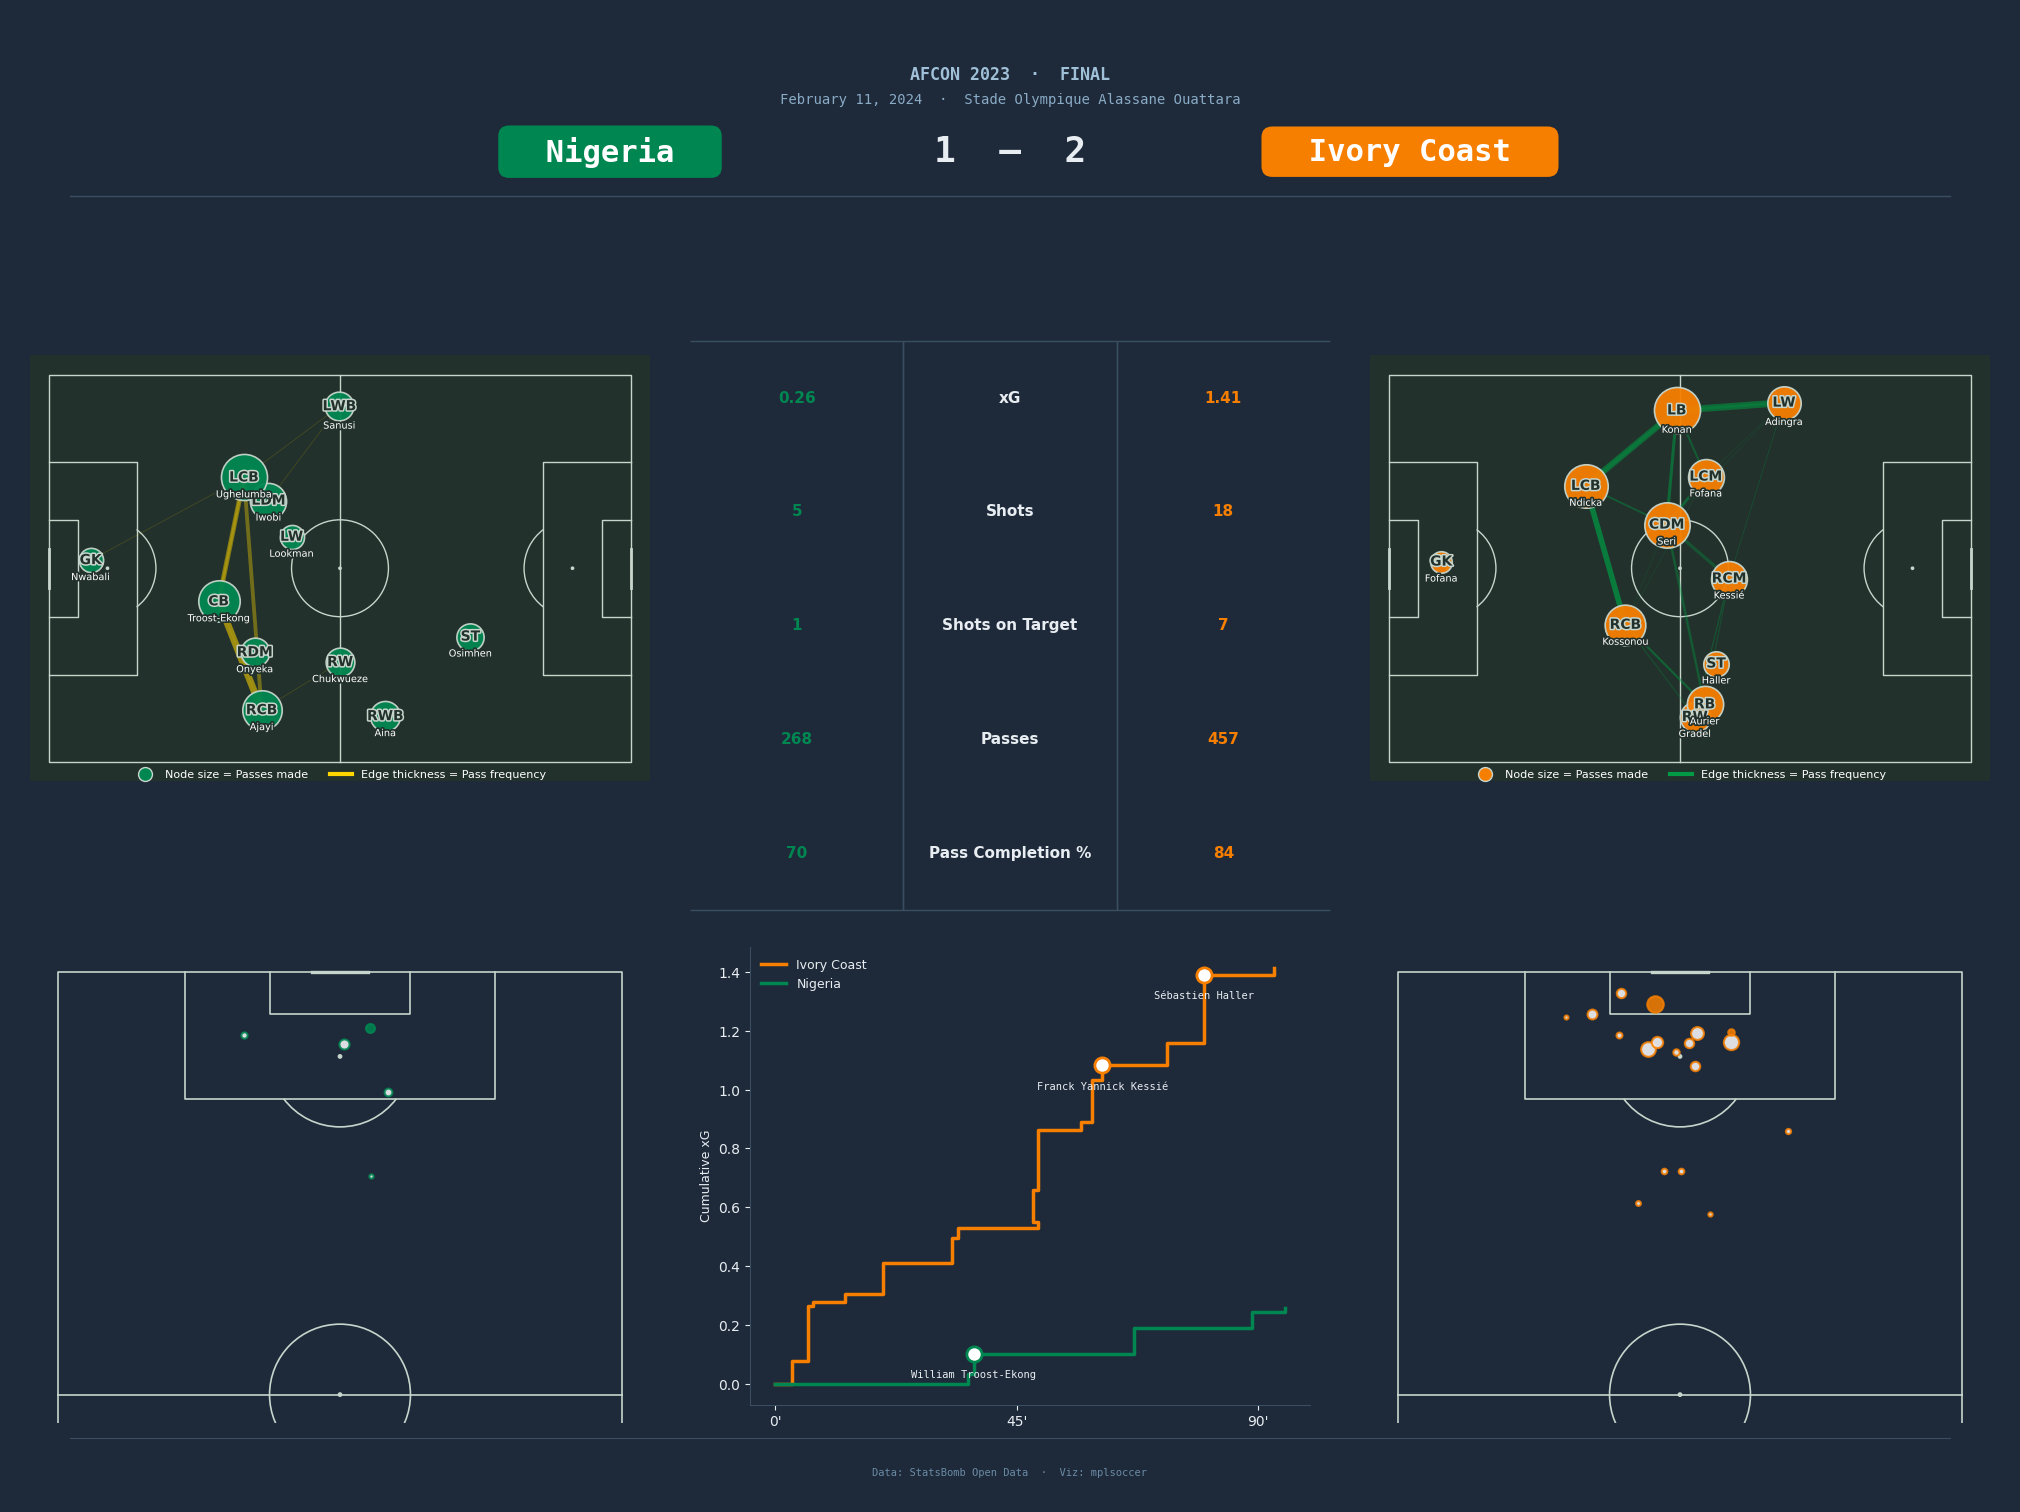

Dashboard saved.


In [10]:
#  AFCON 2023 FINAL- MATCH DASHBOARD
FONT = 'monospace'

fig = plt.figure(figsize=(20, 15), facecolor=DASH_BG)

# Thin top accent bar
bar_ax = fig.add_axes([0, 0.97, 1, 0.03])
bar_ax.set_facecolor(NIGERIA_COLOR)
bar_ax.axis('off')
# Two-colour split: Nigeria green left, Ivory Coast orange right
bar_ax2 = fig.add_axes([0.5, 0.97, 0.5, 0.03])
bar_ax2.set_facecolor(IVORYCOAST_COLOR)
bar_ax2.axis('off')

# Header / title 
ax_header = fig.add_axes([0.0, 0.88, 1.0, 0.09])
ax_header.set_facecolor(DASH_BG)
ax_header.axis('off')

ax_header.text(0.50, 0.92, 'AFCON 2023  ·  FINAL',
               fontsize=12, ha='center', va='top',
               color='#A0C0D8', fontfamily=FONT, fontweight='bold',
               transform=ax_header.transAxes)
ax_header.text(0.50, 0.72, 'February 11, 2024  ·  Stade Olympique Alassane Ouattara',
               fontsize=10, ha='center', va='top',
               color='#8AABC5', fontfamily=FONT,
               transform=ax_header.transAxes)

# Team name pills + score
ng = ax_header.text(0.30, 0.28, '  Nigeria  ',
                     fontsize=22, ha='center', va='center',
                     color='white', fontfamily=FONT, fontweight='bold',
                     transform=ax_header.transAxes)
ng.set_bbox(dict(facecolor=NIGERIA_COLOR, edgecolor='none', boxstyle='round,pad=0.35'))

ax_header.text(0.50, 0.28, '1  –  2',
               fontsize=26, ha='center', va='center',
               color=TEXT_COLOR, fontfamily=FONT, fontweight='bold',
               transform=ax_header.transAxes)

ic = ax_header.text(0.70, 0.28, '  Ivory Coast  ',
                     fontsize=22, ha='center', va='center',
                     color='white', fontfamily=FONT, fontweight='bold',
                     transform=ax_header.transAxes)
ic.set_bbox(dict(facecolor=IVORYCOAST_COLOR, edgecolor='none', boxstyle='round,pad=0.35'))

# Thin divider line
fig.add_artist(mlines.Line2D([0.03, 0.97], [0.876, 0.876],
                              transform=fig.transFigure,
                              color='#3A4E62', linewidth=1.0))

# Section labels 
def section_label(fig, x, y, txt):
    ax = fig.add_axes([x, y, 0.28, 0.018])
    ax.set_facecolor(DASH_BG); ax.axis('off')
    ax.text(0.5, 0.5, txt, ha='center', va='center',
            fontsize=8, color='#8AABC5', fontfamily=FONT,
            fontweight='bold', transform=ax.transAxes, 
            style='italic')
    return ax

section_label(fig, 0.01, 0.861, '')
section_label(fig, 0.36, 0.861, '')
section_label(fig, 0.70, 0.861, '')

#  Pass Networks 
ax4 = fig.add_axes([0.01, 0.40, 0.31, 0.455])
create_passnetwork(
    team_name_str = 'Nigeria',
    ax            = ax4,
    match_id      = match_id,
    node_color    = NIGERIA_COLOR,
    edge_color    = '#FFD700',
    bg            = PITCH_COLOR,
    line          = LINE_COLOR,
)

ax6 = fig.add_axes([0.68, 0.40, 0.31, 0.455])
create_passnetwork(
    team_name_str = "Côte d'Ivoire",
    ax            = ax6,
    match_id      = match_id,
    node_color    = IVORYCOAST_COLOR,
    edge_color    = '#009A44',
    bg            = PITCH_COLOR,
    line          = LINE_COLOR,
)

# Stats Table 
ax5 = fig.add_axes([0.34, 0.40, 0.32, 0.455])
ax5.set_facecolor(DASH_BG)
column_labels, table_vals = create_table(teamA, teamB)

table = ax5.table(
    cellText=table_vals,
    colLabels=['', '', ''],
    cellLoc='center',
    loc='center',
    bbox=[0.0, 0.0, 1.0, 1.0]
)
table.set_fontsize(13)

for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor('#3A4E62')
    cell.PAD = 0.08
    if i == 0:   # Header
        bgs = [NIGERIA_COLOR, '#2A3A4E', IVORYCOAST_COLOR]
        fgs = ['white', TEXT_COLOR, 'white']
        cell.set_facecolor(bgs[j])
        cell.set_text_props(color=fgs[j], fontweight='bold', fontsize=11)
        cell.visible_edges = 'B'
    else:
        cell.set_facecolor('#243347' if i % 2 == 0 else DASH_BG)
        if j == 1:
            cell.set_text_props(fontweight='bold', color=TEXT_COLOR, fontsize=11)
        else:
            # Colour team values with their team colour
            tc = NIGERIA_COLOR if j == 0 else IVORYCOAST_COLOR
            cell.set_text_props(color=tc, fontsize=13, fontweight='bold')
        # Borders
        edges = {0: 'R', 1: 'LR', 2: 'L'}
        if i == len(table_vals):
            edges = {0: 'RB', 1: 'LRB', 2: 'LB'}
        cell.visible_edges = edges.get(j, '')
ax5.axis('off')

#  Bottom section labels 
section_label(fig, 0.01, 0.386, '')
section_label(fig, 0.36, 0.386, '')
section_label(fig, 0.70, 0.386, '')

#  Shot Maps 
ax7 = fig.add_axes([0.01, 0.055, 0.31, 0.325])
create_shotmap(teamA, ax7, team_color=NIGERIA_COLOR)
ax7.axis('off')

ax9 = fig.add_axes([0.68, 0.055, 0.31, 0.325])
create_shotmap(teamB, ax9, team_color=IVORYCOAST_COLOR)
ax9.axis('off')

# xG Flow Chart 
ax8 = fig.add_axes([0.37, 0.07, 0.28, 0.305])
ax8.set_facecolor(DASH_BG)
create_xg_flow_chart(df, ax8)

#  Footer 
fig.add_artist(mlines.Line2D([0.03, 0.97], [0.048, 0.048],
                              transform=fig.transFigure,
                              color='#3A4E62', linewidth=0.8))
ax_footer = fig.add_axes([0.0, 0.005, 1.0, 0.04])
ax_footer.set_facecolor(DASH_BG); ax_footer.axis('off')
ax_footer.text(0.5, 0.5, 'Data: StatsBomb Open Data  ·  Viz: mplsoccer',
               ha='center', va='center', fontsize=7.5,
               color='#6A8BA5', fontfamily=FONT,
               transform=ax_footer.transAxes)

plt.savefig('../images/afcon2023_final_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=DASH_BG)
plt.show()
print("Dashboard saved.")
